# DSMarket - Preparación de los datos para mostrar en Dashboard

El objetivo de este notebook es importar los datos recibidos y unirlos en una tabla para exportar a PowerBI para poder representarlos.

Al final del presente notebook hemos incluido el código del modelo Prophet mediante el cuál realizamos las predicciones diarias de cada producto juntando todas las tiendas.

## 1. Librerías y rutas de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from prophet import Prophet

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

c:\Users\Jon Mikel.DESKTOP-Q1JUAAF\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
sales_data_path = r"data\item_sales.csv"
calendar_data_path = r"data\daily_calendar_with_events.csv"
prices_data_path = r"data\item_prices.csv"

## 2. Importación de las tablas

### 2.1. Ventas

In [3]:
pd_sales = pd.read_csv(sales_data_path, sep = ",")
print("The shape of the sales datataframe is :", pd_sales.shape)

The shape of the sales datataframe is : (30490, 1920)


In [4]:
pd_sales.head()

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,2,2,0,0,0,1,1,0,2,0,1,1,2,0,1,0,0,0,2,1,0,1,1,2,0,0,0,0,0,0,0,1,0,1,0,1,0,3,1,1,0,1,1,2,0,0,0,0,1,1,0,0,0,0,3,0,1,0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,2,0,0,0,0,1,1,2,0,0,0,0,2,0,0,1,1,1,1,0,0,0,0,0,1,2,2,0,1,0,0,0,0,1,2,1,0,0,0,0,0,1,0,3,0,1,2,1,0,3,

In [5]:
pd_sales.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 1920 columns):
 #     Column      Dtype
---    ------      -----
 0     id          str  
 1     item        str  
 2     category    str  
 3     department  str  
 4     store       str  
 5     store_code  str  
 6     region      str  
 7     d_1         int64
 8     d_2         int64
 9     d_3         int64
 10    d_4         int64
 11    d_5         int64
 12    d_6         int64
 13    d_7         int64
 14    d_8         int64
 15    d_9         int64
 16    d_10        int64
 17    d_11        int64
 18    d_12        int64
 19    d_13        int64
 20    d_14        int64
 21    d_15        int64
 22    d_16        int64
 23    d_17        int64
 24    d_18        int64
 25    d_19        int64
 26    d_20        int64
 27    d_21        int64
 28    d_22        int64
 29    d_23        int64
 30    d_24        int64
 31    d_25        int64
 32    d_26        int64
 33    d_27        int64


How many **stores** are there in the data?

In [6]:
print("There are {} stores in the data, and the number of registers per store are: ".format(pd_sales.store.nunique()))
pd_sales.store.value_counts()

There are 10 stores in the data, and the number of registers per store are: 


store
Greenwich_Village    3049
Harlem               3049
Tribeca              3049
Brooklyn             3049
South_End            3049
Roxbury              3049
Back_Bay             3049
Midtown_Village      3049
Yorktown             3049
Queen_Village        3049
Name: count, dtype: int64

How many **items**?

In [7]:
print("There are {} items in the data, and the number of registers per item are: ".format(pd_sales.item.nunique()))
pd_sales.item.value_counts()

There are 3049 items in the data, and the number of registers per item are: 


item
ACCESORIES_1_001     10
ACCESORIES_1_002     10
ACCESORIES_1_003     10
ACCESORIES_1_004     10
ACCESORIES_1_005     10
                     ..
SUPERMARKET_3_823    10
SUPERMARKET_3_824    10
SUPERMARKET_3_825    10
SUPERMARKET_3_826    10
SUPERMARKET_3_827    10
Name: count, Length: 3049, dtype: int64

And **departments**?

In [8]:
print("There are {} departments in the data, and the number of registers per department are: ".format(pd_sales.department.nunique()))
pd_sales.department.value_counts()

There are 7 departments in the data, and the number of registers per department are: 


department
SUPERMARKET_3      8230
HOME_&_GARDEN_1    5320
HOME_&_GARDEN_2    5150
ACCESORIES_1       4160
SUPERMARKET_2      3980
SUPERMARKET_1      2160
ACCESORIES_2       1490
Name: count, dtype: int64

Do we have one register per id? In other words, can two registers have the same id?

In [9]:
print(pd_sales.shape)
print(pd_sales.id.drop_duplicates().shape)

(30490, 1920)
(30490,)


In [10]:
pd_sales[pd_sales.id == 'ACCESORIES_1_002_NYC_1'].T

,1
id,ACCESORIES_1_002_NYC_1
item,ACCESORIES_1_002
category,ACCESORIES
department,ACCESORIES_1
store,Greenwich_Village
...,...
d_1909,1
d_1910,0
d_1911,0
d_1912,0


In [11]:
pd_sales.isnull().sum().sort_values(ascending=True)

d_1906    0
d_1907    0
d_1908    0
d_1909    0
d_1910    0
         ..
d_29      0
d_30      0
d_31      0
d_32      0
d_33      0
Length: 1920, dtype: int64

### 2.2. Calendario y eventos

In [12]:
pd_calendar = pd.read_csv(calendar_data_path, sep = ",")
print("The shape of the calendar datataframe is :", pd_calendar.shape)

The shape of the calendar datataframe is : (1913, 5)


In [13]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [14]:
pd_calendar.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         1913 non-null   str  
 1   weekday      1913 non-null   str  
 2   weekday_int  1913 non-null   int64
 3   d            1913 non-null   str  
 4   event        26 non-null     str  
dtypes: int64(1), str(4)
memory usage: 117.5 KB


In [15]:
print("The range of dates available are: {} - {}".format(pd_calendar['date'].min(),pd_calendar['date'].max()))

The range of dates available are: 2011-01-29 - 2016-04-24


What sort of events do we have?

In [16]:
pd_calendar.event.value_counts(dropna=False)

event
NaN               1887
SuperBowl            6
Ramadan starts       5
Thanksgiving         5
NewYear              5
Easter               5
Name: count, dtype: int64

We don't have a lot of events, but we can think about including additional ones in a later stage (it might help!)

### 2.3. Precios

Esta tabla tiene carácter semanal que habrá que pasar a diario

In [17]:
pd_prices = pd.read_csv(prices_data_path, sep = ",")
print("The shape of the prices datataframe is :", pd_prices.shape)

The shape of the prices datataframe is : (6965706, 5)


In [18]:
pd_prices.head()

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,328.00",12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,329.00",12.74
2,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,330.00",10.99
3,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,331.00",10.99
4,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,332.00",10.99


In [19]:
pd_prices.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 6965706 entries, 0 to 6965705
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        str    
 1   category    str    
 2   store_code  str    
 3   yearweek    float64
 4   sell_price  float64
dtypes: float64(2), str(3)
memory usage: 491.7 MB


Same number of items in the prices data?

In [20]:
print("There are {} items in the data, and the number of registers per item are: ".format(pd_prices.item.nunique()))
pd_prices.item.value_counts()

There are 3049 items in the data, and the number of registers per item are: 


item
ACCESORIES_1_010       2870
ACCESORIES_1_022       2870
ACCESORIES_1_023       2870
ACCESORIES_1_028       2870
ACCESORIES_1_032       2870
                       ... 
HOME_&_GARDEN_1_308     652
HOME_&_GARDEN_1_159     633
HOME_&_GARDEN_1_242     610
SUPERMARKET_3_296       602
SUPERMARKET_2_379       543
Name: count, Length: 3049, dtype: int64

The number of items does match, but there are many registers per item. It seems that prices per item can change with time

Let's take a loook at the variables distribution of the prices dataframe

In [21]:
pd_prices.describe()

,yearweek,sell_price
count,"6,721,786.00","6,965,706.00"
mean,"201,382.42",5.52
std,145.02,4.39
min,"201,105.00",0.01
25%,"201,248.00",2.62
50%,"201,410.00",4.20
75%,"201,515.00",7.18
max,"201,617.00",134.15


In [22]:
pd_prices.describe(include=['object'])

,item,category,store_code
count,6965706,6965706,6965706
unique,3049,3,10
top,ACCESORIES_1_010,SUPERMARKET,BOS_2
freq,2870,3239821,713960


In [23]:
pd_prices.yearweek.isnull().sum()/pd_prices.shape[0]

np.float64(0.03501726888846586)

In [24]:
pd_prices.loc[pd_prices['yearweek'].isnull()]

,item,category,store_code,yearweek,sell_price
149,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
150,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
151,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
152,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
153,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
...,...,...,...,...,...
6965701,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965702,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965703,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965704,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20


Se eliminan las filas con dato de fecha nulo (3.5%)

Además, la columna 'yearweek' se pasa a tipo 'int'

In [25]:
pd_prices = pd_prices.dropna(subset=['yearweek'])
pd_prices['yearweek'] = pd_prices['yearweek'].astype(int)

In [26]:
pd_prices.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 6721786 entries, 0 to 6965697
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        str    
 1   category    str    
 2   store_code  str    
 3   yearweek    int64  
 4   sell_price  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 528.1 MB


In [27]:
pd_prices['sell_price'].isnull().sum()/pd_prices.shape[0]

np.float64(0.0)

In [28]:
pd_prices.reset_index(drop=True, inplace=True)

In [29]:
pd_prices_sorted = pd_prices.sort_values(by=['item', 'store_code','yearweek']).reset_index(drop=True)

In [30]:
pd_prices_sorted.info()

<class 'pandas.DataFrame'>
RangeIndex: 6721786 entries, 0 to 6721785
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        str    
 1   category    str    
 2   store_code  str    
 3   yearweek    int64  
 4   sell_price  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 476.9 MB


## 3. Gestión de las tablas para la unión

### 3.1. Calendario: 
Adición de las columnas ['yearweek', 'is_Ramadan', 'is_Event'] y eventos de 'Christmas' e 'Independence Day'

In [31]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [32]:
pd_calendar['event'] = pd_calendar['event'].fillna("NoEvent")

In [33]:
pd_calendar.isnull().sum()

date           0
weekday        0
weekday_int    0
d              0
event          0
dtype: int64

In [34]:
from datetime import datetime, timedelta
def weekyearnum(dt):
    return dt.strftime("%Y%W")

def myweekyearnum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weekyearnum(offsetdt)

def weeknum(dt):
    return dt.isocalendar()[1]

def myweeknum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weeknum(offsetdt)

In [35]:
## Merge
pd_calendar['date'] = pd.to_datetime(pd_calendar['date'], format = "%Y-%m-%d")

pd_calendar['yearweek'] = pd_calendar['date'].apply(lambda x: myweekyearnum(x)).astype(int)

In [36]:
pd_calendar.loc[pd_calendar['event']=="Ramadan starts"]

,date,weekday,weekday_int,d,event,yearweek
184,2011-08-01,Monday,3,d_185,Ramadan starts,201131
538,2012-07-20,Friday,7,d_539,Ramadan starts,201229
892,2013-07-09,Tuesday,4,d_893,Ramadan starts,201327
1247,2014-06-29,Sunday,2,d_1248,Ramadan starts,201426
1601,2015-06-18,Thursday,6,d_1602,Ramadan starts,201524


In [37]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 25) & (pd_calendar['date'].dt.month == 12), 'event'] = "Christmas"

In [38]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 4) & (pd_calendar['date'].dt.month == 7), 'event'] = "Independence_Day"

In [39]:
pd_calendar['is_Ramadan'] = 0

ramadan_starts = pd_calendar.loc[pd_calendar['event'] == 'Ramadan starts', 'date']

for start_date in ramadan_starts:
    mask = (pd_calendar['date'] >= start_date) & (pd_calendar['date'] < start_date + pd.Timedelta(days=30))
    
    pd_calendar.loc[
        mask,
        'is_Ramadan'
    ] = 1

In [40]:
pd_calendar.rename(columns={'d': 'day'}, inplace=True)

In [41]:
pd_calendar['is_Event'] = pd_calendar['event'].apply(lambda x: 0 if x == "NoEvent" else 1)

In [42]:
pd_calendar.sample(20)


,date,weekday,weekday_int,day,event,yearweek,is_Ramadan,is_Event
1859,2016-03-02,Wednesday,5,d_1860,NoEvent,201609,0,0
635,2012-10-25,Thursday,6,d_636,NoEvent,201243,0,0
583,2012-09-03,Monday,3,d_584,NoEvent,201236,0,0
1855,2016-02-27,Saturday,1,d_1856,NoEvent,201609,0,0
276,2011-11-01,Tuesday,4,d_277,NoEvent,201144,0,0
1440,2015-01-08,Thursday,6,d_1441,NoEvent,201501,0,0
1863,2016-03-06,Sunday,2,d_1864,NoEvent,201610,0,0
1243,2014-06-25,Wednesday,5,d_1244,NoEvent,201425,0,0
1333,2014-09-23,Tuesday,4,d_1334,NoEvent,201438,0,0
296,2011-11-21,Monday,3,d_297,NoEvent,201147,0,0


In [43]:
pd_calendar = pd_calendar.sort_values(['yearweek', 'date'])

### 3.2. Ventas: paso de formato semanal a diario 

In [44]:
pd_sales.set_index(['id','item','category','department','store','store_code','region']).head()

,,,,,,,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,d_244,d_245,d_246,d_247,d_248,d_249,d_250,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
id,item,category,department,store,store_code,region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [45]:
for c in pd_sales.columns:
    if pd_sales[c].dtype == 'object':
        pd_sales[c] = pd_sales[c].astype('category')

In [46]:
pd_sales_long = pd_sales.melt(
    id_vars=['id','item','category','department','store','store_code','region'],
    var_name='day',
    value_name='sales'
)

In [47]:
pd_sales_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 9 columns):
 #   Column      Dtype
---  ------      -----
 0   id          str  
 1   item        str  
 2   category    str  
 3   department  str  
 4   store       str  
 5   store_code  str  
 6   region      str  
 7   day         str  
 8   sales       int64
dtypes: int64(1), str(8)
memory usage: 9.1 GB


In [48]:
pd_sales_long.loc[pd_sales_long['id'] == 'ACCESORIES_1_005_NYC_1']

,id,item,category,department,store,store_code,region,day,sales
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
30494,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_2,0
60984,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_3,0
91474,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_4,0
121964,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_5,0
...,...,...,...,...,...,...,...,...,...
58174924,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1909,1
58205414,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1910,2
58235904,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1911,2
58266394,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1912,2


### 3.3. Captación de primera venta
Dado que hay productos que se pusieron a la venta después del comienzo del dataset (>21-01-2011), al hacer una unión de tablas tendrán valores nulos de precio dado que no hay datos de ello. Por esta razón, se capta la fecha de primera venta y de primer precio y se hace una unión de datos con fechas en las que los productos estaban efectivamente a la venta. (La gestión de nulos de PowerBI es buena, pero preferimos realizar este ejercicio a modo de limpieza y tener un dataset con menor volumen)

In [49]:
pd_sales_long = pd_sales_long.merge(
    pd_calendar[['day', 'date', 'yearweek']],
    left_on='day',
    right_on='day',
    how='left'
)

In [50]:
pd_sales_long

,id,item,category,department,store,store_code,region,day,sales,date,yearweek
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
...,...,...,...,...,...,...,...,...,...,...,...
58327365,SUPERMARKET_3_823_PHI_3,SUPERMARKET_3_823,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,1,2016-04-24,201617
58327366,SUPERMARKET_3_824_PHI_3,SUPERMARKET_3_824,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,0,2016-04-24,201617
58327367,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,0,2016-04-24,201617
58327368,SUPERMARKET_3_826_PHI_3,SUPERMARKET_3_826,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,3,2016-04-24,201617


In [51]:
for c in pd_sales_long.columns:
    if pd_sales_long[c].dtype == 'object':
        pd_sales_long[c] = pd_sales_long[c].astype('category')

In [52]:
first_sale = (
    pd_sales_long[pd_sales_long['sales'] > 0]
    .groupby(['item', 'store_code'])['date']
    .min()
    .rename('first_sale_date')
)

In [53]:
first_sale.head()

item              store_code
ACCESORIES_1_001  BOS_1        2013-07-16
                  BOS_2        2013-07-27
                  BOS_3        2013-07-31
                  NYC_1        2013-07-18
                  NYC_2        2013-07-27
Name: first_sale_date, dtype: datetime64[us]

In [54]:
# get first available price per item/store
first_price_week = (
    pd_prices
    .sort_values('yearweek')
    .groupby(['item', 'store_code'])['yearweek']
    .min()
    .rename('first_price_week')
)

In [55]:
first_price_week.head()

item              store_code
ACCESORIES_1_001  BOS_1         201328
                  BOS_2         201330
                  BOS_3         201330
                  NYC_1         201328
                  NYC_2         201330
Name: first_price_week, dtype: int64

In [56]:
week_to_date = (
    pd_calendar
    .groupby('yearweek', as_index=False)['date']
    .min()
)
first_price = (
    first_price_week.reset_index()
    .merge(week_to_date, left_on='first_price_week', right_on='yearweek', how='left')
    [['item', 'store_code', 'date']]
    .rename(columns={'date': 'first_price_date'})
    .set_index(['item', 'store_code'])['first_price_date']
)

In [57]:
first_price

item               store_code
ACCESORIES_1_001   BOS_1        2013-07-13
                   BOS_2        2013-07-27
                   BOS_3        2013-07-27
                   NYC_1        2013-07-13
                   NYC_2        2013-07-27
                                   ...    
SUPERMARKET_3_827  NYC_3        2014-03-29
                   NYC_4        2014-06-21
                   PHI_1        2014-03-01
                   PHI_2        2014-11-01
                   PHI_3        2014-03-01
Name: first_price_date, Length: 30490, dtype: datetime64[us]

In [58]:
first_activity = pd.concat([first_sale, first_price], axis=1)
first_activity['start_date'] = first_activity.min(axis=1)

In [59]:
first_activity

first_sale_date first_price_date start_date
item              store_code                                            
ACCESORIES_1_001  BOS_1           2013-07-16       2013-07-13 2013-07-13
                  BOS_2           2013-07-27       2013-07-27 2013-07-27
                  BOS_3           2013-07-31       2013-07-27 2013-07-27
                  NYC_1           2013-07-18       2013-07-13 2013-07-13
                  NYC_2           2013-07-27       2013-07-27 2013-07-27
...                                      ...              ...        ...
SUPERMARKET_3_827 NYC_3           2014-04-04       2014-03-29 2014-03-29
                  NYC_4           2014-06-23       2014-06-21 2014-06-21
                  PHI_1           2014-03-07       2014-03-01 2014-03-01
                  PHI_2           2014-11-04       2014-11-01 2014-11-01
                  PHI_3           2014-03-04       2014-03-01 2014-03-01

[30490 rows x 3 columns]

In [60]:
first_activity.index.is_unique

True

In [61]:
first_activity.reset_index().duplicated(['item', 'store_code']).sum()

np.int64(0)

In [62]:
pd_sales_long_daily = pd_sales_long.merge(
    first_activity[['start_date']],
    on=['item', 'store_code'],
    how='left'
)

In [63]:
pd_sales_long_valid_daily = pd_sales_long_daily[
    pd_sales_long_daily['date'] >= pd_sales_long_daily['start_date']
]

### 3.4. Fusión de tablas

In [64]:
df_dsMarket = pd_sales_long_valid_daily.merge(
    pd_calendar[['day', 'event', 'is_Ramadan', 'is_Event']],
    on='day',
    how='left'
)

In [65]:
df_dsMarket = df_dsMarket.merge(
    pd_prices[['item', 'store_code', 'yearweek', 'sell_price']],
    on=['item', 'store_code', 'yearweek'],
    how='left'
)

In [66]:
df_dsMarket = df_dsMarket.astype({
    "sell_price": "float32",
    "yearweek": "int32",
    "sales": "int32",
    "item": "category",
    "event": "category",
    "store_code": "category"
})

In [67]:
df_dsMarket.info()

<class 'pandas.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 16 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          str           
 1   item        category      
 2   category    str           
 3   department  str           
 4   store       str           
 5   store_code  category      
 6   region      str           
 7   day         str           
 8   sales       int32         
 9   date        datetime64[us]
 10  yearweek    int32         
 11  start_date  datetime64[us]
 12  event       category      
 13  is_Ramadan  int64         
 14  is_Event    int64         
 15  sell_price  float32       
dtypes: category(3), datetime64[us](2), float32(1), int32(2), int64(2), str(6)
memory usage: 7.3 GB


In [68]:
df_dsMarket.isnull().sum()

id            0
item          0
category      0
department    0
store         0
store_code    0
region        0
day           0
sales         0
date          0
yearweek      0
start_date    0
event         0
is_Ramadan    0
is_Event      0
sell_price    0
dtype: int64

In [69]:
df_dsMarket.sort_values(by=['id', 'date'], inplace=True)

In [70]:
# Adición de Features store_id y revenue
df_dsMarket['store_id'] = df_dsMarket['store_code'].astype(str) + '_' + df_dsMarket['department'].astype(str)
df_dsMarket['revenue'] = df_dsMarket['sales'] * df_dsMarket['sell_price']

In [71]:
df_dsMarket = df_dsMarket.reset_index(drop=True)

In [72]:
df_dsMarket.head()

,id,item,category,department,store,store_code,region,day,sales,date,yearweek,start_date,event,is_Ramadan,is_Event,sell_price,store_id,revenue
0,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_897,0,2013-07-13,201328,2013-07-13,NoEvent,1,0,12.74,BOS_1_ACCESORIES_1,0.00
1,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_898,0,2013-07-14,201328,2013-07-13,NoEvent,1,0,12.74,BOS_1_ACCESORIES_1,0.00
2,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_899,0,2013-07-15,201328,2013-07-13,NoEvent,1,0,12.74,BOS_1_ACCESORIES_1,0.00
3,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_900,1,2013-07-16,201328,2013-07-13,NoEvent,1,0,12.74,BOS_1_ACCESORIES_1,12.74
4,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_901,3,2013-07-17,201328,2013-07-13,NoEvent,1,0,12.74,BOS_1_ACCESORIES_1,38.22


## 4. Creación de tabla central 'fact_sales' y tablas dimensionales
El objetivo de esta tabla es tener centralizada la información relevante como fecha, producto, tienda, ventas o precio y tener otras tablas con la información adicional: tabla de tiendas con región o departamento, tabla de calendario con eventos, tabla producto con categoría.

In [73]:
fact_sales = df_dsMarket.drop(columns=['id', 'category','department', 'region', 'store','day', 'event', 'is_Ramadan', 'yearweek', 'is_Event'])

In [74]:
fact_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 8 columns):
 #   Column      Dtype         
---  ------      -----         
 0   item        category      
 1   store_code  category      
 2   sales       int32         
 3   date        datetime64[us]
 4   start_date  datetime64[us]
 5   sell_price  float32       
 6   store_id    str           
 7   revenue     float64       
dtypes: category(2), datetime64[us](2), float32(1), float64(1), int32(1), str(1)
memory usage: 2.7 GB


In [75]:
fact_sales.duplicated(
    subset=['item', 'store_code', 'date']
).sum()

np.int64(0)

In [76]:
fact_sales = fact_sales.sort_values(['item', 'store_code', 'date'])

In [77]:
fact_sales.head()

,item,store_code,sales,date,start_date,sell_price,store_id,revenue
0,ACCESORIES_1_001,BOS_1,0,2013-07-13,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
1,ACCESORIES_1_001,BOS_1,0,2013-07-14,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
2,ACCESORIES_1_001,BOS_1,0,2013-07-15,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
3,ACCESORIES_1_001,BOS_1,1,2013-07-16,2013-07-13,12.74,BOS_1_ACCESORIES_1,12.74
4,ACCESORIES_1_001,BOS_1,3,2013-07-17,2013-07-13,12.74,BOS_1_ACCESORIES_1,38.22


### Tablas dimensionales
Creación de las tablas con la información adicional.

In [78]:
# Extract unique item-category combinations
dim_items = pd_sales[['item', 'category']].drop_duplicates().reset_index(drop=True)

# Optional: rename columns to standard dimension table style
dim_items = dim_items.rename(columns={'item': 'item_id', 'category': 'item_category'})

# Inspect
dim_items.head()

,item_id,item_category
0,ACCESORIES_1_001,ACCESORIES
1,ACCESORIES_1_002,ACCESORIES
2,ACCESORIES_1_003,ACCESORIES
3,ACCESORIES_1_004,ACCESORIES
4,ACCESORIES_1_005,ACCESORIES


In [79]:
# Extract unique store info
dim_stores = pd_sales[['store_code', 'store', 'department', 'region']].drop_duplicates().reset_index(drop=True)

# Optional: rename columns
dim_stores = dim_stores.rename(columns={
    'store_code': 'store_code',
    'store': 'store_name',
    'department': 'store_department',
    'region': 'store_region'
})

# Inspect
dim_stores.head()

,store_code,store_name,store_department,store_region
0,NYC_1,Greenwich_Village,ACCESORIES_1,New York
1,NYC_1,Greenwich_Village,ACCESORIES_2,New York
2,NYC_1,Greenwich_Village,HOME_&_GARDEN_1,New York
3,NYC_1,Greenwich_Village,HOME_&_GARDEN_2,New York
4,NYC_1,Greenwich_Village,SUPERMARKET_1,New York


In [80]:
dim_calendar = pd_calendar.sort_values('date').copy()

In [81]:
# In dim_stores
dim_stores['store_id'] = dim_stores['store_code'].astype(str) + '_' + dim_stores['store_department'].astype(str)

# Keep only relevant columns in dim_stores
dim_stores = dim_stores[['store_id', 'store_name', 'store_region', 'store_department']].drop_duplicates()

In [82]:
# Items
assert dim_items['item_id'].is_unique, "Items table has duplicates!"

# Stores
assert dim_stores['store_id'].is_unique, "Stores table has duplicates!"

 ### Exportación de las tablas en formato parquet

In [83]:
# fact_sales.to_parquet(r"data\fact_sales.parquet", index = False)
# dim_items.to_parquet(r'data\dim_items.parquet', index=False)
# dim_stores.to_parquet(r'data\dim_stores.parquet', index=False)
# dim_calendar.to_parquet(r'data\dim_calendar.parquet', index=False)
# df_dsMarket.to_parquet(r"data\dsMarket.parquet", index = False)

## 5. Análisis de Nueva York, Boston y Filadelfia
El análisis más detallado se realiza mediante el Dashboard

### Relación precio vs popularidad (mismo item, diferente ciudad y precio)

In [84]:
item_state = (
    df_dsMarket
    .groupby(["item", "region"])
    .agg(
        total_sales=("sales", "sum"),
        avg_price=("sell_price", "mean"),
        days_sold=("sales", "count")
    )
    .reset_index()
)

In [85]:
state_totals = (
    item_state
    .groupby("region")["total_sales"]
    .sum()
    .rename("state_total")
)

item_state = item_state.merge(
    state_totals, on="region"
)

item_state["popularity_share"] = (1000*
    item_state["total_sales"] /
    item_state["state_total"]
)

In [86]:
multi_state_items = (
    item_state
    .groupby("item")["region"]
    .nunique()
)

valid_items = multi_state_items[multi_state_items >= 3].index

item_state = item_state[item_state["item"].isin(valid_items)]

In [87]:
item_state.head()

,item,region,total_sales,avg_price,days_sold,state_total,popularity_share
0,ACCESORIES_1_001,Boston,1047,11.01,3023,18899006,0.06
1,ACCESORIES_1_001,New York,2535,11.00,4047,28675547,0.09
2,ACCESORIES_1_001,Philadelphia,511,11.09,3016,18120856,0.03
3,ACCESORIES_1_002,Boston,878,5.28,5529,18899006,0.05
4,ACCESORIES_1_002,New York,1596,5.27,7274,28675547,0.06


<Axes: xlabel='avg_price', ylabel='popularity_share'>

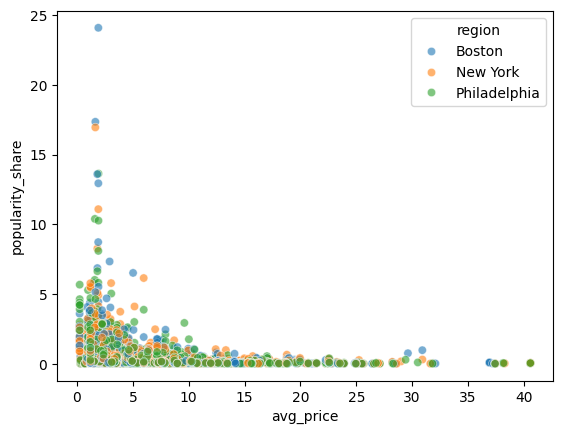

In [88]:
sns.scatterplot(
    data=item_state,
    x="avg_price",
    y="popularity_share",
    hue="region",
    alpha=0.6
)

In [89]:
price_pop_corr = (
    item_state
    .groupby("item")
    .apply(lambda x: x["avg_price"].corr(x["popularity_share"]))
    .rename("price_pop_corr")
    .reset_index()
)

In [90]:
price_pop_corr

,item,price_pop_corr
0,ACCESORIES_1_001,-0.90
1,ACCESORIES_1_002,0.61
2,ACCESORIES_1_003,1.00
3,ACCESORIES_1_004,0.29
4,ACCESORIES_1_005,-0.08
...,...,...
3044,SUPERMARKET_3_823,0.35
3045,SUPERMARKET_3_824,0.80
3046,SUPERMARKET_3_825,-0.94
3047,SUPERMARKET_3_826,0.86


In [91]:
item_support = (
    item_state
    .groupby("item")
    .agg(
        n_states=("region", "nunique"),
        price_std=("avg_price", "std"),
        pop_std=("popularity_share", "std")
    )
    .reset_index()
)

In [92]:
price_pop_corr = price_pop_corr.merge(
    item_support, on="item", how="left"
)

In [93]:
q_low = price_pop_corr["price_pop_corr"].quantile(0.25)
q_high = price_pop_corr["price_pop_corr"].quantile(0.75)

In [94]:
def price_segment(x):
    if pd.isna(x):
        return "insufficient_data"
    elif x >= q_high:
        return "premium"
    elif x <= q_low:
        return "price_sensitive"
    else:
        return "neutral"

price_pop_corr["price_segment"] = (
    price_pop_corr["price_pop_corr"].apply(price_segment)
)

In [95]:
item_popularity = (
    item_state
    .groupby("item")["total_sales"]
    .sum()
    .rename("total_sales")
)

price_pop_corr = price_pop_corr.merge(
    item_popularity, on="item"
)

In [96]:
sales_threshold = price_pop_corr["total_sales"].quantile(0.6)

best_items = price_pop_corr[
    (price_pop_corr["total_sales"] >= sales_threshold) &
    (price_pop_corr["price_segment"].isin(["premium", "price_sensitive"]))
]

In [97]:
best_items.sort_values("pop_std", ascending = False).head(10)

,item,price_pop_corr,n_states,price_std,pop_std,price_segment,total_sales
2450,SUPERMARKET_3_226,-0.96,3,0.00,6.43,price_sensitive,363082
2476,SUPERMARKET_3_252,-0.94,3,0.00,4.85,price_sensitive,565299
2314,SUPERMARKET_3_090,1.00,3,0.02,3.91,premium,1002529
2918,SUPERMARKET_3_694,-1.00,3,0.00,3.49,price_sensitive,390001
2542,SUPERMARKET_3_318,0.86,3,0.01,1.90,premium,260598
2659,SUPERMARKET_3_435,0.94,3,0.01,1.80,premium,99356
2426,SUPERMARKET_3_202,-0.90,3,0.07,1.80,price_sensitive,295689
1706,SUPERMARKET_1_096,0.94,3,1.31,1.36,premium,92357
2267,SUPERMARKET_3_042,0.67,3,0.01,1.31,premium,92924
2007,SUPERMARKET_2_181,-0.87,3,0.09,1.23,price_sensitive,138531


In [98]:
best_items.sort_values("price_pop_corr", ascending = False).head()

,item,price_pop_corr,n_states,price_std,pop_std,price_segment,total_sales
2314,SUPERMARKET_3_090,1.00,3,0.02,3.91,premium,1002529
2733,SUPERMARKET_3_509,1.00,3,0.02,0.10,premium,18706
918,HOME_&_GARDEN_1_361,1.00,3,0.00,0.11,premium,27028
415,ACCESORIES_1_424,1.00,3,0.08,0.04,premium,15307
2386,SUPERMARKET_3_162,1.00,3,0.08,0.08,premium,17941


In [99]:
df_dsMarket.info()

<class 'pandas.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 18 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          str           
 1   item        category      
 2   category    str           
 3   department  str           
 4   store       str           
 5   store_code  category      
 6   region      str           
 7   day         str           
 8   sales       int32         
 9   date        datetime64[us]
 10  yearweek    int32         
 11  start_date  datetime64[us]
 12  event       category      
 13  is_Ramadan  int64         
 14  is_Event    int64         
 15  sell_price  float32       
 16  store_id    str           
 17  revenue     float64       
dtypes: category(3), datetime64[us](2), float32(1), float64(1), int32(2), int64(2), str(7)
memory usage: 8.8 GB


In [100]:
df_dsMarket.loc[df_dsMarket['start_date'] < '2011-02-01']

,id,item,category,department,store,store_code,region,day,sales,date,yearweek,start_date,event,is_Ramadan,is_Event,sell_price,store_id,revenue
36250,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_1,1,2011-01-29,201105,2011-01-29,NoEvent,0,0,5.77,BOS_1_ACCESORIES_1,5.77
36251,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_2,2,2011-01-30,201105,2011-01-29,NoEvent,0,0,5.77,BOS_1_ACCESORIES_1,11.54
36252,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_3,1,2011-01-31,201105,2011-01-29,NoEvent,0,0,5.77,BOS_1_ACCESORIES_1,5.77
36253,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_4,0,2011-02-01,201105,2011-01-29,NoEvent,0,0,5.77,BOS_1_ACCESORIES_1,0.00
36254,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_5,2,2011-02-02,201105,2011-01-29,NoEvent,0,0,5.77,BOS_1_ACCESORIES_1,11.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46010251,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1909,1,2016-04-20,201616,2011-01-29,NoEvent,0,0,4.78,PHI_3_SUPERMARKET_3,4.78
46010252,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1910,0,2016-04-21,201616,2011-01-29,NoEvent,0,0,4.78,PHI_3_SUPERMARKET_3,0.00
46010253,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1911,0,2016-04-22,201616,2011-01-29,NoEvent,0,0,4.78,PHI_3_SUPERMARKET_3,0.00
46010254,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1912,1,2016-04-23,201617,2011-01-29,NoEvent,0,0,4.78,PHI_3_SUPERMARKET_3,4.78


## 6. Predicción Prophet

### Funcion forecasting

In [101]:
def plot_item_forecast(item_name):
    
    df_item = (
        df_dsMarket[df_dsMarket['item'] == item_name]
        .groupby('date', as_index=False)
        .agg({
            'sales': 'sum',
            'sell_price': 'mean',   # or weighted if you want later
            'is_Event': 'max',
            'is_Ramadan': 'max',
            'event': 'first'
        })
    )
#------- SPLIT TRAIN TEST -------    
    df_item = df_item.sort_values('date')

    #for logistic growth, we need to set a floor and cap
    df_item['floor'] = 0
    df_item['cap'] = df_item['sales'].max()

    split_date = df_item['date'].quantile(0.8)  # 80% train

    train = df_item[df_item['date'] <= split_date]
    test  = df_item[df_item['date'] > split_date]

#------- TRAIN TEST for PROPHET ------- 
    train_prophet = train[['date','sales','sell_price','is_Ramadan']]\
        .rename(columns={'date':'ds','sales':'y'})
    test_prophet = test[['date','sales','sell_price','is_Ramadan']]\
        .rename(columns={'date':'ds','sales':'y'})

#------- HOLIDAYS ------- 
    holidays = (
        df_item[df_item['event'] != 'NoEvent'][['date', 'event']]
        .drop_duplicates()
        .rename(columns={'date': 'ds', 'event': 'holiday'})
    )
    holidays['lower_window'] = -2   # 2 days before
    holidays['upper_window'] = 1    # 1 days after

#------- MODEL -------
    model = Prophet(
        holidays=holidays,
        seasonality_mode='multiplicative',
        #growth='logistic',
        yearly_seasonality=True,
        daily_seasonality=False
    )

    model.add_seasonality(name='weekly', period=7, fourier_order=3, prior_scale=0.1) # the less the better, but it already has limitations

    model.add_regressor('sell_price')
    model.add_regressor('is_Ramadan')

    model.fit(train_prophet)

#------- FORECAST -------
    future = test_prophet[['ds', 'sell_price', 'is_Ramadan']]\
        .rename(columns = {'date':'ds'})
    forecast = model.predict(future)
    
#------- MAE ------- 
    print(len(test)+ len(train))
    forecast_test = forecast.set_index('ds').loc[test['date']]

    mae = mean_absolute_error(test['sales'], forecast_test['yhat'])

    print("MAE:", mae)

#------- PLOT ------- 
    fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

    # --- Top plot: Train + Test + Forecast ---
    axes[0].plot(test['date'], test['sales'], label='Test')
    axes[0].plot(forecast['ds'], forecast['yhat'], label='Forecast')
    axes[0].plot(train['date'], train['sales'], label='Train', color='gray', alpha=0.5)
    axes[0].set_title('Prophet Forecast vs Actuals')
    axes[0].legend()

    # --- Bottom plot: Test + Forecast only ---
    axes[1].plot(test['date'], test['sales'], label='Test')
    axes[1].plot(forecast['ds'], forecast['yhat'], label='Forecast')
    axes[1].set_title('Test vs Forecast (Zoom)')
    axes[1].legend()
    axes[1].fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

    return forecast


18:36:08 - cmdstanpy - INFO - Chain [1] start processing
18:36:09 - cmdstanpy - INFO - Chain [1] done processing


1122
MAE: 4.210287499458076


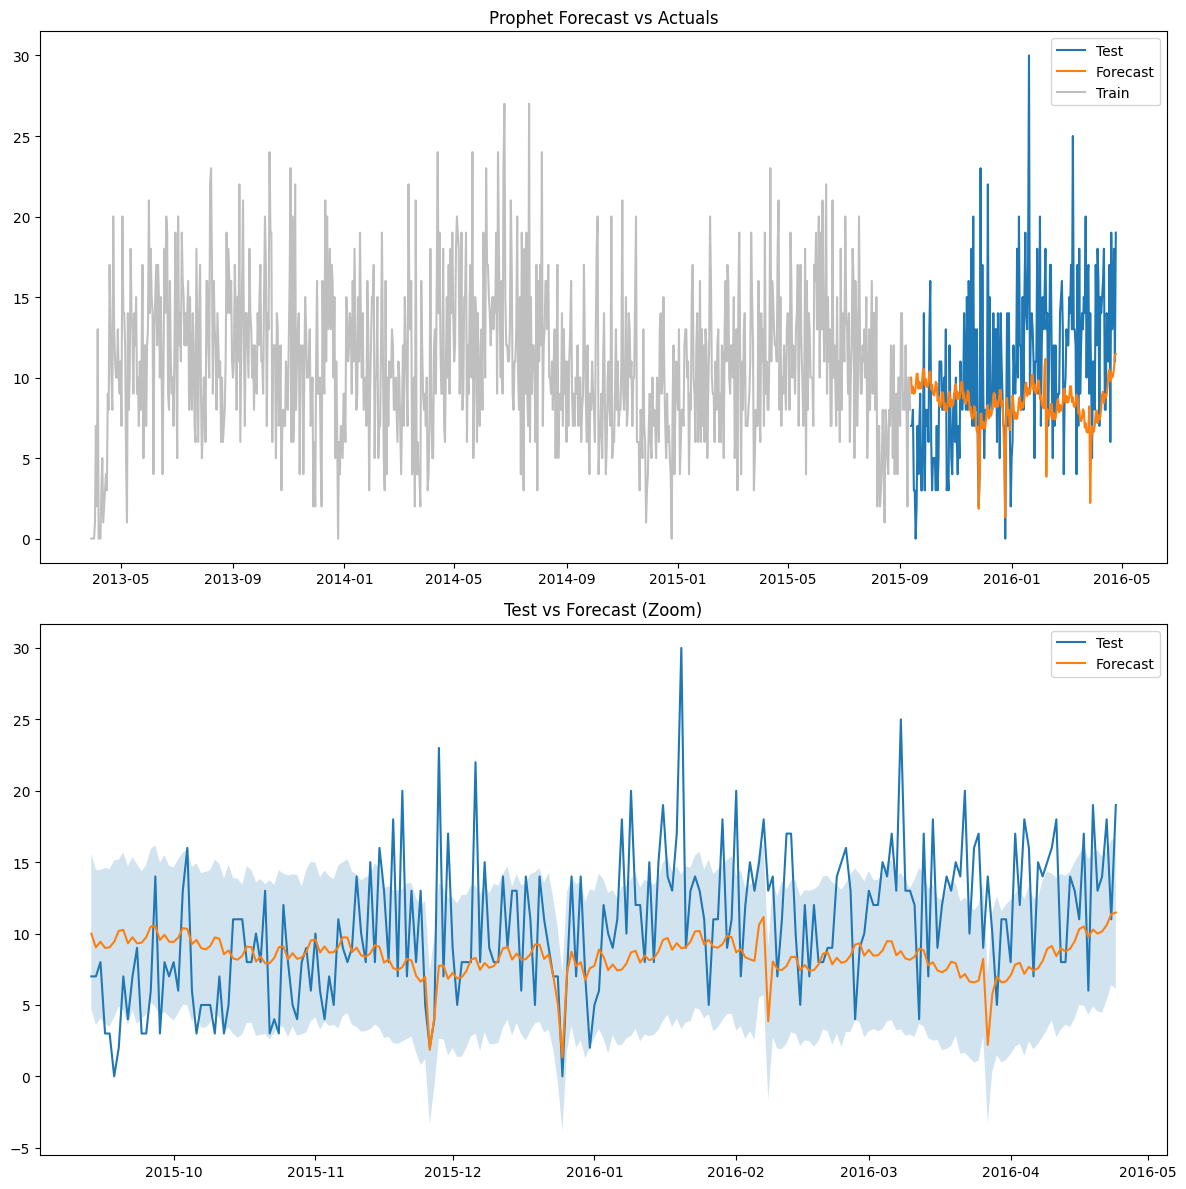

In [102]:
prophet_forecast = plot_item_forecast('SUPERMARKET_3_826')